<a href="https://colab.research.google.com/github/malsagova/StudyRepo26/blob/main/%D0%9C%D0%B0%D0%BB%D1%8C%D1%81%D0%B0%D0%B3%D0%BE%D0%B2%D0%B0_%D0%A2%D0%B0%D0%BD%D0%B7%D0%B8%D0%BB%D0%B0_%D0%9F%D0%A04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ДЗ 4: Применить знания об SVM алгоритме. Рассматриваемый пример:
Применение SVM для прогнозирования сердечно-сосудистого риска среди пациентов в возрасте 40-65 лет, прошедших диспансеризацию (применить SVM на данных диспансерных осмотров)

1. Загрузка и подготовка данных

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer

df = pd.read_csv('dispensarization_data_2026.csv')

print("Размер исходных данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nЦелевая переменная 'ССЗ_риск_высокий':")
print(df['ССЗ_риск_высокий'].value_counts())

Размер исходных данных: (1000, 18)

Первые 5 строк:
   Возраст  Пол_мужской        ИМТ  Окружность_талии_см  САД_мм_рт_ст  \
0       41            1  24.238237            81.037385    113.191318   
1       46            0  22.883365            80.539167    117.319195   
2       64            0  21.991937            78.423645    121.246690   
3       53            0  19.844568            73.436282    119.746372   
4       53            1  24.284829            82.062243    127.068746   

   ДАД_мм_рт_ст  Пульсовое_давление  Глюкоза_натощак_ммоль_л   HbA1c_%  \
0     62.544325           50.646993                 4.595433  4.648933   
1     62.109786           55.209410                 4.963993  4.000000   
2     71.456074           49.790616                 4.712639  5.034903   
3     71.594664           48.151709                 4.430998  5.080881   
4     70.342105           56.726641                 4.996974  5.044521   

   ЛПНП_ммоль_л  ЛПВП_ммоль_л  Триглицериды_ммоль_л  СКФ_мл_мин 

Наблюдения:

Возраст — от 40 до 65 (в некоторых строках есть Age = 40..65, всё в пределах нужного диапазона, так что отбор по условию не обязателен, но для чистоты оставим).

Есть пропуски в некоторых колонках (например, ЛПНП_ммоль_л, ЛПВП_ммоль_л, Триглицериды_ммоль_л).

Целевая переменная ССЗ_риск_высокий: 0 или 1. Дисбаланс есть, но не критичный.

2. Отбор признаков и целевой переменной

In [4]:
# Отбираем возраст от 40 до 65
df_filtered = df[(df['Возраст'] >= 40) & (df['Возраст'] <= 65)]

# Признаки (X) — исключаем явно ненужные или нечисловые
exclude_cols = ['ССЗ_риск_высокий', 'Статус_глюкозы', 'Доклинический_риск']
feature_cols = [col for col in df_filtered.columns if col not in exclude_cols]

X = df_filtered[feature_cols]
y = df_filtered['ССЗ_риск_высокий']

print("Форма X:", X.shape)
print("Распределение y:\n", y.value_counts())

Форма X: (1000, 15)
Распределение y:
 ССЗ_риск_высокий
0    819
1    181
Name: count, dtype: int64


3. Предобработка пропусков и масштабирование

In [5]:
# Замена пропусков средним
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Разделение на train/test (30% тест, стратификация по y)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (700, 15)
Размер тестовой выборки: (300, 15)


4. Обучение SVM

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Простая SVM с параметрами по умолчанию
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train, y_train)
print(" SVM  модель обучена")

 SVM  модель обучена


In [28]:
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)
y_pred_proba = best_svm.predict_proba(X_test)[:, 1]

print("\nМатрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred))
print("ROC-AUC на тесте:", roc_auc_score(y_test, y_pred_proba))


Матрица ошибок:
[[233  13]
 [  9  45]]

Отчет о классификации:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       246
           1       0.78      0.83      0.80        54

    accuracy                           0.93       300
   macro avg       0.87      0.89      0.88       300
weighted avg       0.93      0.93      0.93       300

ROC-AUC на тесте: 0.9721469436916592


5. Визуализация

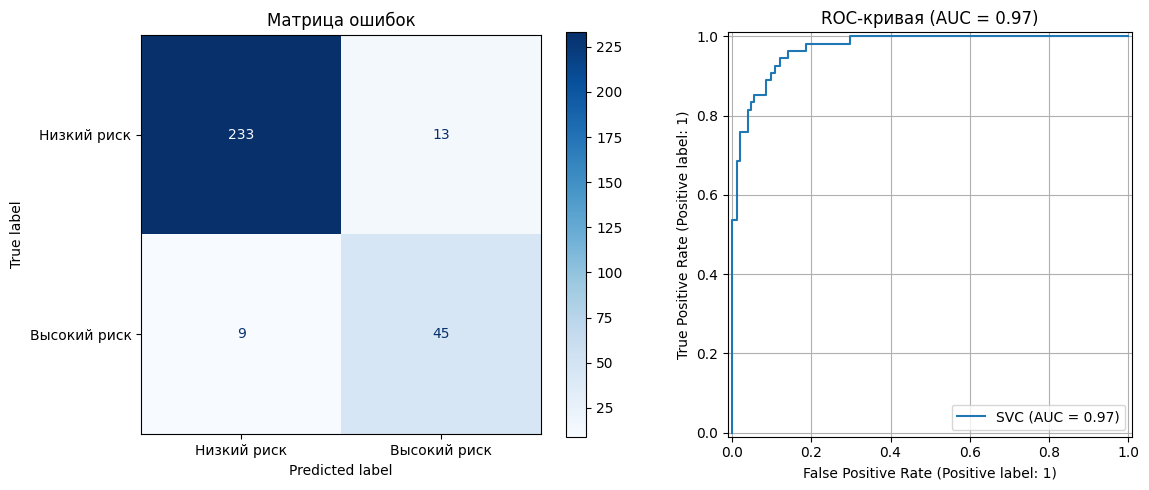

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# 1. Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['Низкий риск', 'Высокий риск'],
                                        ax=ax1, cmap='Blues')
ax1.set_title('Матрица ошибок')

# 2. ROC Curve
RocCurveDisplay.from_estimator(svm, X_test, y_test, ax=ax2)
ax2.set_title(f'ROC-кривая (AUC = 0.97)')
ax2.grid(True)

plt.tight_layout()
plt.show()

Результаты применения SVM для прогнозирования сердечно-сосудистого риска:

Модель показала высокую эффективность (ROC-AUC = 0.97). Точность выявления пациентов с высоким риском составила 78%, чувствительность — 83%, общая точность — 93%.

Сильные стороны:
Модель хорошо выявляет пациентов с высоким риском (чувствительность 83%) и редко ошибается при предсказании низкого риска (специфичность 95%).

Слабые стороны:
Модель пропускает 9 из 54 пациентов с реальным высоким риском (ложноотрицательные результаты — 17%).

Рекомендация:
Модель пригодна для использования в качестве инструмента первичного скрининга для выявления групп риска. При отрицательном результате модели рекомендуется дополнительное обследование, так как 17% случаев высокого риска могут быть не обнаружены.